In [26]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
import re
from nltk.stem import WordNetLemmatizer
nltk.download("stopwords")
nltk.download("wordnet")
stop_words=set(stopwords.words("english"))


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nice\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\nice\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [27]:
df=pd.read_csv(r"IMDB.csv")
df

,review,sentiment
0,Film version of Sandra Bernhard's one-woman of...,negative
1,I switched this on (from cable) on a whim and ...,positive
2,The `plot' of this film contains a few holes y...,negative
3,"Some amusing humor, some that falls flat, some...",negative
4,What can you say about this movie? It was not ...,negative
...,...,...
995,"Not exactly a new story line, but this romanti...",negative
996,I first saw this movie as a younger child. My ...,positive
997,Some people have stated that as of the 11th se...,positive
998,Nothing but the director's juvenile fantasy co...,negative


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     1000 non-null   object
 1   sentiment  1000 non-null   object
dtypes: object(2)
memory usage: 15.8+ KB


In [29]:
df.isna().sum()

review       0
sentiment    0
dtype: int64

In [30]:
df.duplicated().sum()

np.int64(0)

In [32]:
def lemmatiztion(text):
    lemmatizer=WordNetLemmatizer()
    text = text.split()
    text = [lemmatizer.lemmatize(word) for word in text]
    return " ".join(text)
def lower_case(text):
    return text.lower()
def remove_punctuation(text):
    return re.sub(r'[^\w\s]', '', text)
def remove_stopwords(text):
    text= text.split()
    text= [word for word in text if word not in stop_words]
    return " ".join(text)
def remove_numbers(text):
    text=text.split()
    text=[word for word in text if not word.isdigit()]
    return " ".join(text)
def remove_url(text):
    return re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
def preprocess_text(text):
    text= lower_case(text)
    text= remove_punctuation(text)
    text= remove_stopwords(text)
    text= lemmatiztion(text)
    text= remove_numbers(text)
    text= remove_url(text)
    return text
df["clean_review"] = df["review"].apply(preprocess_text)
df.head()

,review,sentiment,clean_review
0,Film version of Sandra Bernhard's one-woman of...,negative,film version sandra bernhards onewoman offbroa...
1,I switched this on (from cable) on a whim and ...,positive,switched cable whim treated quite surprisealth...
2,The `plot' of this film contains a few holes y...,negative,plot film contains hole could drive massive tr...
3,"Some amusing humor, some that falls flat, some...",negative,amusing humor fall flat decent acting quite at...
4,What can you say about this movie? It was not ...,negative,say movie terrible good two day earlier watche...


In [33]:
df["review"].str.len().describe()

count    1000.000000
mean     1312.690000
std      1005.221885
min        80.000000
25%       695.000000
50%       966.000000
75%      1562.750000
max      7164.000000
Name: review, dtype: float64

In [34]:
print(df["review"][1])
print(df["clean_review"][1])

I switched this on (from cable) on a whim and was treated to quite a surprise...although very predictable this film turned out to be quite enjoyable...no big stars but well-directed and just plain fun. With all the over-hyped crap that is out there it is very nice to get an unexpected surprise now and then... and this little film fits the bill nicely. 9/10
switched cable whim treated quite surprisealthough predictable film turned quite enjoyableno big star welldirected plain fun overhyped crap nice get unexpected surprise little film fit bill nicely


<Axes: xlabel='sentiment', ylabel='count'>

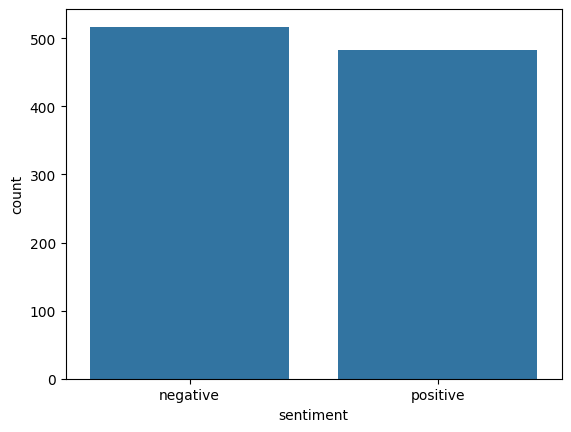

In [31]:
sns.countplot(x=df["sentiment"])

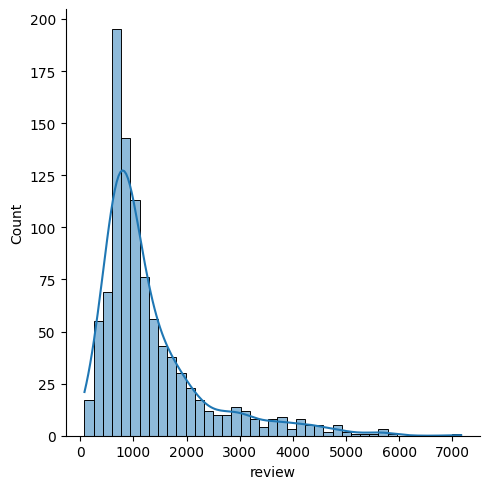

In [ ]:
sns.displot(df["review"].str.len(), kde=True)

<Axes: ylabel='review'>

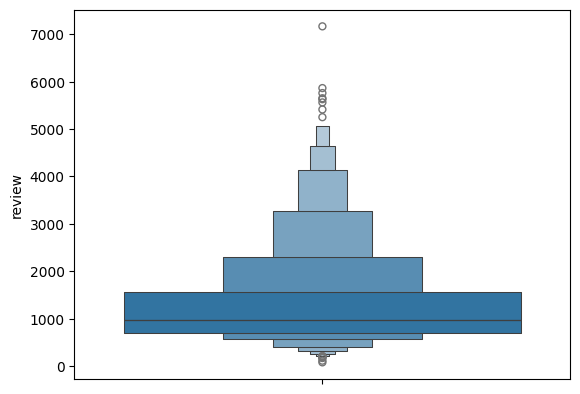

In [40]:
sns.boxenplot(df["review"].str.len())

Text(0.5, 1.0, 'Negative Reviews')

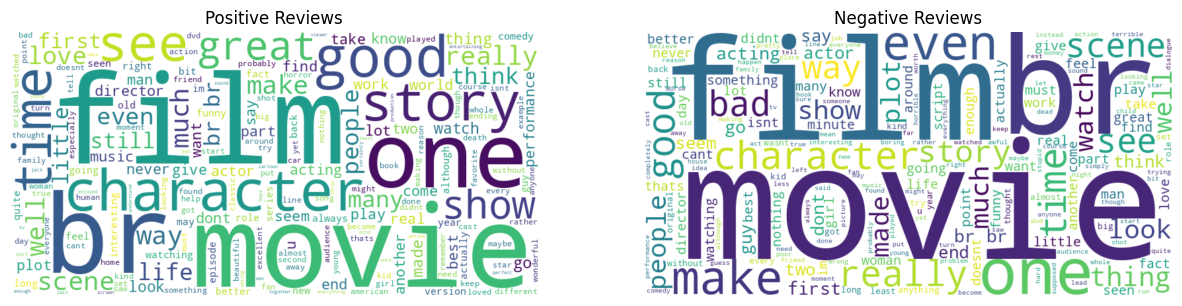

In [ ]:
from wordcloud import WordCloud
positive_reviews= df[df["sentiment"] == "positive"]["clean_review"]
negative_reviews= df[df["sentiment"] == "negative"]["clean_review"]
positive_text= " ".join(positive_reviews)
negative_text= " ".join(negative_reviews)
positive_wordcloud = WordCloud(width=800, height=400, background_color="white").generate(positive_text)
negative_wordcloud = WordCloud(width=800, height=400, background_color="white").generate(negative_text)
plt.figure(figsize=(15, 12))
plt.subplot(1, 2, 1)
plt.imshow(positive_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Reviews")
plt.subplot(1, 2, 2)
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Reviews")